# PV–SST Allen Cell: Local Input & Synapse Builder (ChatGPT Refactor)

This notebook is the **local environment** driver for:
- Building Allen Institute biophysical cells (PV, SST, etc.).
- Generating structured synaptic inputs (bio-derived, background, custom).
- Attaching synapses and spike trains using modular Python files in `modules_external/`.

All NEURON cell logic and input generation live in `.py` files inside `modules_external/`.  
This notebook will only:
1. Configure simulation and synapse parameters.
2. Call the appropriate functions/classes from `modules_external/`.
3. Run simulations and visualize results for verification.

A separate notebook will later provide a fully bootstrapped version for Google Colab or fresh environments (5_colab.ipynb).


In [1]:
# Dev helper: autoreload modules_local and ensure repo on sys.path
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
repo_root = Path('/home/hrbncv/PV-SST').resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))


In [2]:
import os, sys, csv, json, h5py, random, math, pickle
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

from allensdk.api.queries.biophysical_api import BiophysicalApi
from allensdk.model.biophys_sim.config import Config
from allensdk.model.biophysical.utils import Utils


# from modules_local import download_cell

from modules_local import load_cell
from modules_local import geometry
from modules_local import inputs
from modules_local import synapses

from modules_local import run_sim
from modules_local import plotting


--No graphics will be displayed.


In [3]:
cell_name = 'SST2' #SST, SST2, PV, PN
tunes_dir = 'tunes'
model_dir = 'seg_tuned' #f'OriginalFromAllenDB/{specimen_id}_{model_type}' # or None=tunes_dir


os.chdir(f"cells/{cell_name}")

# http://celltypes.brain-map.org/mouse/experiment/electrophysiology/'specimen_id'
spec_ids = {'SST':476686112, 'SST2': 485466109, 'PV': 484635029}
specimen_id = spec_ids[cell_name] #SST 476686112, SST2 485466109, PV 484635029, 571709783

soma_diam_multis = {'SST':6, 'SST2':8, 'PV':6}
soma_diam_multiplier = soma_diam_multis[cell_name] #SST 6, SST2 8, PV 6

os.chdir(f'{tunes_dir}/{model_dir}')

In [4]:
from neuron import h
h.load_file("stdrun.hoc")  # Required to use h.run()
h.nrn_load_dll("modfiles/x86_64/.libs/libnrnmech.so")

1.0

# Step 2 — Build Cell

This section constructs a single NEURON cell, ready for simulation, in four substeps:

2.1 **Load Cell**  
: Build the NEURON cell object from the tuned model files.

2.2 **Define Geometry**  
: Create a standardized geometry view with named segment groups (e.g. soma, proximal dendrites).

2.3 **Generate Inputs**  
: Generate spike trains for each synapse group (homogeneous, inhomogeneous, fixed, etc.), independent of morphology.

2.4 **Add Synapses**  
: Place synapses on the cell using the geometry groups and attach spike trains via VecStim/NetCon.


## 2.1 Load Cell

In this step, we construct the NEURON cell object from the tuned model files.  
The notebook will pass a configuration dictionary (`cell_config`) to a single function `load_cell(...)` in `modules_local`, which internally handles all model-specific details (e.g., Allen vs custom, manifest paths, soma tuning).  
The result is a `cell` handle that owns the NEURON sections and is ready for further processing.


In [5]:
# Minimal cell configuration for the current tuned Allen model
# May become json later if necessary
cell_config = {
    # "backend": "allen", # could be used for specifying which model in future
    "cell_name": cell_name,  # defined in Step 1
    "paths": {
        # CWD is expected to be the tuned model directory:
        #   ../cells/<cell_name>/tunes/seg_tuned/
        "manifest": Path("manifest.json"),
    },
    # Optional tuning parameters; extend later as needed
    "tuning": {
        "soma_diam_multiplier": 6.0,
    },
}

In [6]:
"""
Step 2.1 — Load Cell

Build the NEURON cell object from the tuned Allen model.

Requirements:
- Working directory is already the tuned model folder (e.g. cells/PV/tunes/seg_tuned).
- manifest.json is present in the current directory.
- NEURON and MOD mechanisms are already loaded in Step 1.
"""

try:
    from modules_local.load_cell import load_cell
except ImportError as e:
    raise ImportError(
        "Could not import modules_local.load_cell. "
        "Create modules_local/load_cell.py with a `load_cell(cell_config)` "
        "function before running Step 2.1."
    ) from e


cell = load_cell(cell_config)

print("Loaded cell:", cell)


Loaded Allen cell for 'SST2' from manifest.json, soma_diam_multiplier=6.0, Vinit=-85.0
Loaded cell: LoadedCell(label='SST2')


## 2.2 Define Geometry

Here we create a standardized geometry view of the cell that is independent of how the cell was originally built.  
Given the `cell` and a configuration dictionary (`geom_config`), the function `define_geometry(...)` in `modules_local` will group segments into named sets (e.g., `soma`, `prox_dend`, `dist_dend`, `all_dend`) and compute path distances from a defined origin.  
The result is a `geom` structure that maps group names to lists of target locations `(sec, x, dist_um)` for synapse placement.


In [7]:
# Example geometry configuration for an Allen PV cell;
# Later will become json and refined
geom_config = {
    "label": f"{cell_name}_default_geometry",

    # Where distances are measured from
    "distance_origin": {
        "kind": "soma",   # future: "section_name", "custom_point", etc.
        "x": 0.5,
    },

    # Current thresholds (used now) – matches old behavior
    "thresholds_um": {
        "proximal": {"low": 20.0,  "high": 100.0},
        "distal":   {"low": 100.0, "high": None},   # None = no upper bound
    },

    # FUTURE: finer radial bands for more granular control
    "radial_bands": [
        {"name": "band_0_50",   "low": 0.0,   "high": 50.0},
        {"name": "band_50_150", "low": 50.0,  "high": 150.0},
        {"name": "band_150p",   "low": 150.0, "high": None},
    ],

    # FUTURE: section-name / type patterns to define region families
    "section_patterns": {
        "soma":   {"kinds": ["soma"]},
        "dend":   {"kinds": ["dend"]},
        "apic":   {"kinds": ["apic"]},
        "axon":   {"kinds": ["axon"]},
        # Example name-based patterns for pyramidal cells, etc.
        "basal_dend":  {"name_contains": ["basal"]},
        "apical_dend": {"name_contains": ["apic", "apical"]},
    },

    # FUTURE: high-level group specs, mapping names to rules
    "group_specs": {
        "soma": {
            "source": "section_patterns",
            "pattern_key": "soma",
        },
        "proximal": {
            "source": "radial_bands",
            "band_name": "band_20_100",  # could be defined in radial_bands later
        },
        "distal": {
            "source": "thresholds_um",
            "threshold_key": "distal",
        },
        "all_dend": {
            "source": "section_patterns",
            "pattern_key": "dend",
        },
    },
}


In [8]:
"""
Step 2.2 — Define Geometry

Create a standardized geometry view of the cell:
- name groups of segments (e.g. soma, prox_dend, dist_dend, all_dend).
- store NEURON (sec, x, dist_um) triplets for each group.

This step should be model-agnostic, given a `cell` and a `geom_config`.
"""

try:
    from modules_local.geometry import define_geometry
except ImportError as e:
    raise ImportError(
        "Could not import modules_local.geometry. "
        "Create modules_local/geometry.py with a `define_geometry(cell, geom_config)` "
        "function before running Step 2.2."
    ) from e


geom = define_geometry(cell, geom_config)

print("Geometry label:", geom.get("label", "<unnamed>"))
print("Geometry groups:", list(geom.get("groups", {}).keys()))

Geometry defined for 'SST2': 1 soma segs, 54 proximal dend segs, 52 distal dend segs, 115 total dend segs.
Geometry label: SST2_default_geometry
Geometry groups: ['soma', 'proximal', 'distal', 'all_dend']


## 2.3 Generate Inputs

In this step we generate spike trains for each synapse group, completely separate from the cell morphology.  
The function `generate_inputs(...)` in `modules_local` will use `input_config`, `sim_params`, and `syn_params` to create spike-time arrays from various source types (e.g., fixed trains, homogeneous Poisson, inhomogeneous bio traces, baseline+bio windows).  
The output `inputs` is a pure Python/NumPy structure (no NEURON objects) organized per population and synapse group.


In [9]:
from pathlib import Path
from modules_local import inputs

# working dir = tune folder
sim_cfg_preview, groups_cfg_preview = inputs.check_inputs()
print("Simulation config preview:", sim_cfg_preview)
print("Groups config preview:", groups_cfg_preview)

=== check_inputs: synapse config summary ===
Sim cfg: {'cell': 'SST2', 'tune': 'seg_tuned', 'color': 'm', 'load': None, 'output': None, 'output_format': 'pkl', 'n_trials': 1, 'n_traces_to_save': 1, 'tstart': 500.0, 'tstop': 1200.0, 'dt': 0.025, 'param_study': {'input_type': None, 'param_type': None, 'param_vals': [], 'n_trials': None}, 'randomness': {'global': {'state': True, 'seed': None}, 'trials': 'derived', 'inputs': 'derived', 'timing': {'tstart': None, 'tstop': None, 'jitter': None}, 'synapses': {'placement': 'derived', 'weights': 'derived', 'dynamics': None}, 'modes': {'homogeneous_poisson': 'derived', 'inhomogeneous_poisson': 'derived', 'precomputed': None}}, 'jitter': None, 'seed': None, 'trial_randomness': 'synapses'}

Synapse groups:
  - pn_exc        state=True   mode='inhomogeneous_poisson'  source.path='/home/hrbncv/PV-SST/single_cells/Madhu_Data/bio_cell_output/pyrFiringRateAvg.csv'  N_syn=50
  - vip_inh       state=False  mode='precomputed'       source.path='/home/hrbn

In [10]:
# rng = np.random.default_rng(123)

# sim_cfg, groups_cfg, inputs_by_group = stim_inputs.generate_inputs(
#     syn_config_path=syn_cfg_path,
#     geometry=geom,          # or cell.geometry
#     # rng=rng,
# )

# sim_cfg, groups_cfg, inputs_by_group = inputs.generate_inputs("syn_config.json", geometry=geom)
sim_cfg, groups_cfg, inputs_by_group = inputs.generate_inputs(geometry=geom)

# print(inputs_by_group)
print("sim_cfg:", sim_cfg)
print("\nGenerated input groups:")
for name, gi in inputs_by_group.items():
    print(f"  - {name:15s} mode={gi.mode!r:18}  n_trains={len(gi.spike_trains)}")

sim_cfg: {'cell': 'SST2', 'tune': 'seg_tuned', 'color': 'm', 'load': None, 'output': None, 'output_format': 'pkl', 'n_trials': 1, 'n_traces_to_save': 1, 'tstart': 500.0, 'tstop': 1200.0, 'dt': 0.025, 'param_study': {'input_type': None, 'param_type': None, 'param_vals': [], 'n_trials': None}, 'randomness': {'global': {'state': True, 'seed': None}, 'trials': 'derived', 'inputs': 'derived', 'timing': {'tstart': None, 'tstop': None, 'jitter': None}, 'synapses': {'placement': 'derived', 'weights': 'derived', 'dynamics': None}, 'modes': {'homogeneous_poisson': 'derived', 'inhomogeneous_poisson': 'derived', 'precomputed': None}}, 'jitter': None, 'seed': None, 'trial_randomness': 'synapses'}

Generated input groups:
  - pn_exc          mode='inhomogeneous_poisson'  n_trains=50
  - bg_exc          mode='homogeneous_poisson'  n_trains=3382
  - bg_inh          mode='homogeneous_poisson'  n_trains=796
  - bg_exc_del      mode='homogeneous_poisson'  n_trains=20


## 2.4 Add Synapses

Finally, we attach synapses and inputs to the cell.  
The function `add_synapses(...)` in `modules_local` will use `cell`, `geom`, `syn_params`, `sim_params`, and `inputs` to (1) choose synapse locations from geometry groups, (2) create synaptic mechanisms, VecStims, and NetCons, and (3) return a `syn_state` registry summarizing all synapses and connections.  
This completes Step 2 and produces a fully configured cell ready for Step 3 (running simulations).


In [11]:
# === Step 2.4: Attach synapses and VecStim inputs to the cell ===

from modules_local import synapses

# 2.3 outputs: sim_cfg, groups_cfg, inputs_by_group
# 2.1/2.2: cell, geom

syn_state = synapses.add_synapses(
    cell=cell,
    geom=geom,
    sim_cfg=sim_cfg,
    groups_cfg=groups_cfg,
    inputs_by_group=inputs_by_group,
)

print("Step 2.4: synapse attachment complete.")
print("Synapse groups:", list(syn_state.get("synapses", {}).keys()))
for gname, records in syn_state.get("records", {}).items():
    print(f"  {gname}: {len(records)} synapse records")


Step 2.4: synapse attachment complete.
Synapse groups: ['pn_exc', 'bg_exc', 'bg_inh', 'bg_exc_del']
  pn_exc: 50 synapse records
  bg_exc: 3382 synapse records
  bg_inh: 796 synapse records
  bg_exc_del: 20 synapse records


In [12]:
for g, recs in syn_state["records"].items():
    print(g, "n_syn:", len(recs), "example weight:", recs[0].weight, "first spikes:", recs[0].spike_times[:5])
print("Groups configuration:", groups_cfg)
print("Simulation configuration:", sim_cfg.keys())

pn_exc n_syn: 50 example weight: 0.7134730084250563 first spikes: [651.9398474032005, 955.458642633705]
bg_exc n_syn: 3382 example weight: 0.9770055610795138 first spikes: []
bg_inh n_syn: 796 example weight: 0.44418100906980634 first spikes: []
bg_exc_del n_syn: 20 example weight: 0.294378227801167 first spikes: [932.1123124786936, 993.7401992829742, 995.364879566224, 1085.3756794340554, 1197.1685165796298]
Groups configuration: {'pn_exc': {'state': True, 'mode': 'inhomogeneous_poisson', 'source': {'freq': None, 'baseline': 2.0, 'path': '/home/hrbncv/PV-SST/single_cells/Madhu_Data/bio_cell_output/pyrFiringRateAvg.csv', 'bin_ms': 5, 'kind': None, 'time_col': None, 'rate_col': None, 'ref': None, 'key': None}, 'timing': {'onset_ms': None, 'stim_tstart_ms': 600.0, 'duration_ms': None, 'input_stim_tstart_ms': 100, 'input_duration_ms': 550}, 'syns': {'type': 'AMPA_NMDA_STP', 'N_syn': 50, 'segs': 'all', 'dist_func': {'kind': 'uniform', 'params': {'c': 2.0}}, 'params': {'wt_mean': 0.75, 'wt_s

In [13]:
# # Check the input synapse group params
# # to check timing and rates look correct
# from pathlib import Path
# import pandas as pd
# import matplotlib.pyplot as plt
# from modules_local import input_sampling

# tune_dir = Path("/home/hrbncv/PV-SST/single_cells/cells/SST2/tunes/seg_tuned")
# centers, mean_rate, std_rate, sim_cfg, meta, ref_curve = input_sampling.sample_group_rates(
#     tune_dir=tune_dir,
#     group="pn_exc",
#     runs=2000,
#     bin_ms=None,
#     seed=None,
# )


# # Save or inspect
# df = pd.DataFrame({
#     "time_ms": centers,
#     "rate_mean_hz": mean_rate,
#     "rate_std_hz": std_rate,
# })
# df.head()

# # Plot with source curve overlay (if available)
# plt.figure(figsize=(6, 4))
# plt.plot(centers, mean_rate, label="mean")
# plt.fill_between(centers, mean_rate - std_rate, mean_rate + std_rate, alpha=0.2, label="±std")
# if ref_curve:
#     ref_t, ref_r = ref_curve
#     plt.plot(ref_t, ref_r, "--", color="orange", linewidth=1.5, label="source curve")
# plt.xlabel("Time (ms)")
# plt.ylabel("Rate (Hz per synapse)")
# plt.title(f"{meta['group']}: mean of {meta['n_runs']} samples")
# plt.legend()
# plt.tight_layout()
# plt.show()



# Step 3 — Run Simulations

run_sim modes:

3.1 **Single Sim** (run_single)

3.2 **Multi Sim** (run_multi)

3.3 **Parametric Sweep** (run_param)

In [14]:
# === Step 3.1: Run single simulation ===

from modules_local import run_sim

# sim_cfg comes from Step 2.3 and already has dt, tstart, tstop, seed, etc.
# sim_traces = run_sim.run_cell(cell, sim_cfg)
results = run_sim.run_sim(cell, geom, sim_cfg, groups_cfg, inputs_by_group)
run_sim.summarize_results(results)

# single-trial case
T = results["traces"]["T"]
V = results["traces"]["V"]
spikes = results["spikes"]

# # multi-trial case
# T = results["traces"]["T"]
# V_trials = results["traces"]["V"]      # list of V arrays (subset of trials)
# spikes_trials = results["spikes"]      # list of spike-time arrays

mode=single, n_traces_to_save=1
  single: len(T)=48001, len(V)=48001, n_spikes=15


In [15]:
# from modules_local import run_sim, plotting
# from IPython.display import clear_output

# live_rates = []

# def on_trial(data):
#     # accumulate a simple metric
#     live_rates.append(len(data["spikes"]))
#     clear_output(wait=True)
#     plotting.plt.figure(figsize=(4,2))
#     plotting.plt.plot(live_rates)
#     plotting.plt.xlabel("Trial")
#     plotting.plt.ylabel("Spike count")
#     plotting.plt.tight_layout()
#     plotting.plt.show()

# results = run_sim.run_sim(cell, geom, sim_cfg, groups_cfg, inputs_by_group, trial_callback=on_trial)


# Step 4 — Analyze Results

Analyze Results:

4.1 **Cell & Synapse Generation**  

4.2 **Single Sim**  

4.3 **Multi Sim**  

4.4 **Parametric Sim**  

4.5 **Loaded Sim Data**    

4.6 **Multi Loaded Sim Data**  

### Step 4.1 Cell & Synapse Generation

In [16]:
# # === Step 4.1: Analyze / visualize synapse placement ===

# from modules_local import plotting

# # 2.4 output: SynapseRecord dataclasses
# syn_records_new = syn_state["records"]

# # Adapt to the old plotting format: dicts with the expected keys
# syn_records_plot = {}
# for g, recs in syn_records_new.items():
#     syn_records_plot[g] = [
#         {
#             "syn_id":      r.syn_id,
#             "group":       r.group,
#             "type":        r.type,
#             "weight":      r.weight,
#             "distance":    r.distance,
#             "section":     r.section,
#             "x":           r.x,
#             "spike_times": r.spike_times,
#         }
#         for r in recs
#     ]

# # Quick text summary
# for g, recs in syn_records_new.items():
#     if not recs:
#         continue
#     print(
#         f"{g:12s}  n_syn={len(recs)}  "
#         f"example weight={recs[0].weight:.3f}  "
#         f"first spikes={recs[0].spike_times[:5]}"
#     )

# # Distance-density plot for all synapses (same API as old notebook)
# plotting.plot_syn_records(
#     cell,
#     syn_records_plot,
#     plotted_groups=["all"],
#     plotted_props=("distance_density",),
#     plot_type="both",
#     bins=25.0,
#     win_size=25,
# )


In [17]:
# from modules_local import plotting

# def plot_all(results, in_vivo=None, window=(None, None), win_size=25):
#     plotting.plot_results(
#         results,
#         in_vivo_curve=in_vivo,
#         win_size=win_size,
#         plot_window=window,
#         rate_style='line',
#         raster_style='dot',
#     )
#     # Synapse distance/weight plots if available
#     syn_recs = results.get("syn_records") or {}
#     if syn_recs:
#         plotting.plot_syn_records(cell, syn_recs, ['all'], plotted_props=('distance',))
#         plotting.plot_syn_records(cell, syn_recs, ['all'], plotted_props=('weight',))
#         plotting.plot_syn_records(cell, syn_recs, ['all'], plotted_props=('weight', 'distance'))

# # Usage:
# # plot_all(results, in_vivo=(t_s, rate))

# for props in [('distance',), ('weight',), ('weight','distance')]:
#     plotting.plot_syn_records(cell, results.get('syn_records', {}), ['all'], plotted_props=props)


In [18]:
import pandas as pd
import numpy as np

# === Optional: load in-vivo / inhomogeneous rate curve for 'stim' group ===

stim_syn_group = "pn_exc_trace"
in_vivo_curve = '/home/hrbncv/PV-SST/single_cells/Madhu_Data/bio_cell_output/pyrFiringRateAvg.csv'  # default: no overlay

stim_group_cfg = groups_cfg.get(stim_syn_group)
if stim_group_cfg is not None:
    src = stim_group_cfg.get("source", {})

    # Prefer the normalized 'path' field; fall back to 'freq' if you kept it there
    inhom_input_filepath = src.get("path") or src.get("freq")
    if inhom_input_filepath:
        time_col = src.get("time_col") or "Time"
        rate_col = src.get("rate_col") or "AvgFiringRate"

        PFR = pd.read_csv(inhom_input_filepath, delimiter=",")

        mask = PFR[time_col] > 0
        PFR_time_shortened = PFR.loc[mask, time_col].to_numpy()
        PFR_firing_rate_shortened = PFR.loc[mask, rate_col].to_numpy()

        delay_ms = float(sim_cfg.get("delay", 0.0))
        delayed_PFR_t = PFR_time_shortened + delay_ms / 1000.0  # seconds

        in_vivo_curve = (delayed_PFR_t, PFR_firing_rate_shortened)

# If no 'stim' group or no path, in_vivo_curve stays None and the plot just omits it.


Detected 15 spikes (total avg: 13.636363636363635) at times (ms): [ 510.75   628.975  662.1    682.95   709.825  754.225  822.6    847.6
  891.7    937.45   959.975 1004.125 1038.05  1078.175 1116.125]


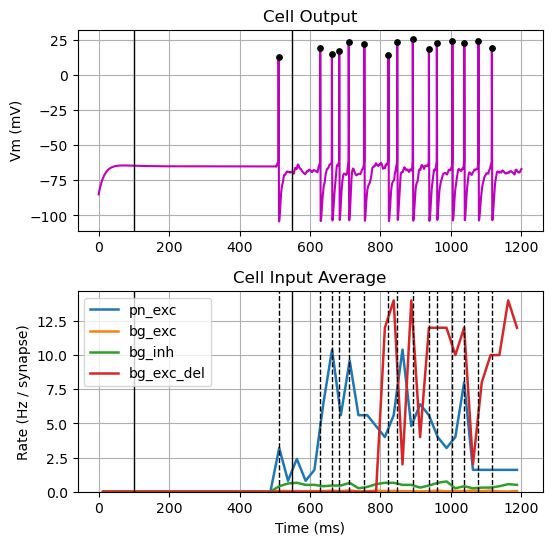

In [19]:
from modules_local import plotting


plotting.plot_results(
    results,
    in_vivo_curve=in_vivo_curve,
    win_size=25,
    raster_style='dot',
    plot_window=(None, None),  # or (None, None) to auto
)

In [20]:
# from modules_local import run_sim
# import hashlib, numpy as np

# def on_trial(d):
#     h = hashlib.md5()
#     for tr in d["traces"].get("V", []): h.update(np.asarray(tr).tobytes())
#     print(f"trial {d['trial_idx']}: spikes={len(d['spikes'])} hash={h.hexdigest()[:8]}")

# results = run_sim.run_sim(cell, geom, sim_cfg, groups_cfg, inputs_by_group, trial_callback=on_trial)


# Extra Modules

In [21]:
err

NameError: name 'err' is not defined

In [ ]:
results = run_sim.run_sim(cell, geom, sim_cfg, groups_cfg, inputs_by_group)
# tweak anything you like (color, meta, etc.)
results["sim_cfg"]["color"] = "m"
results["meta"]["note"] = "batch 1, bg_exc only"

from modules_local import run_sim
run_sim.save_results_with_name(results, "sst2_seg_tuned_bgexc_batch1")


In [ ]:
from modules_local import run_sim

# 1) first batch
sim_cfg["n_trials"] = 200
res1 = run_sim.run_sim(cell, geom, sim_cfg, groups_cfg, inputs_by_group)

# 2) second batch
sim_cfg["n_trials"] = 300
res2 = run_sim.run_sim(cell, geom, sim_cfg, groups_cfg, inputs_by_group)

# 3) merge in memory
merged = run_sim.append_multi_results(res1, res2)

# 4) optionally save merged dataset
run_sim.save_results_with_name(merged, "sst2_seg_tuned_500trials")


In [ ]:
from modules_local import run_sim, plotting

# load directly from disk; ignores current sim_cfg
results = run_sim.load_results("output_data/SST2_seg_tuned_tune1.pkl")

# optional: tweak plot-only fields such as color
results["sim_cfg"]["color"] = "m"

# optional: build in_vivo_curve from current groups_cfg/sim_cfg (if you have them)
# in_vivo_curve = (delayed_PFR_t, PFR_firing_rate_shortened)

plotting.plot_results(results, in_vivo_curve=in_vivo_curve)


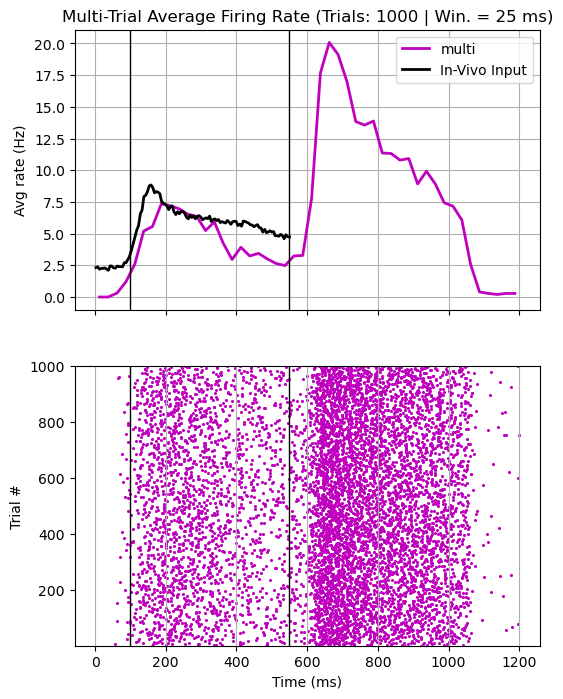

In [ ]:
from modules_local import run_sim, plotting

old_path = "/home/hrbncv/PV-SST/single_cells/cells/SST2/tunes/seg_tuned/output_data/tune1_1000tr1200ms.pkl"

results_old = run_sim.load_old_multi_results(
    old_path,
    label="base tune",
    color="m",      # or whatever you want
    tstop=1200.0,   # ms
    bins=25.0,      # ms
    delay=0.0,      # ms
)

# Now this goes through the same plot_results/plot_multi path as new runs
plotting.plot_results(
    results_old,
    plot_raster=True,
    in_vivo_curve=in_vivo_curve,  # if you want the overlay
)
